# SeaSenseLib Demo 

This notebook demonstrates the capabilities of SeaSenseLib for reading oceanographic instrument data from various formats, writing it to netCDF and making basic plots or statistical calculations.


## Overview

SeaSenseLib is a Python library for reading, converting, and plotting oceanographic sensor data from various instrument formats. It provides:

- **Simple API** with `ssl.read()` and `ssl.write()` functions 
- **Readers** for multiple formats (CNV, NetCDF, RBR, ADCP, etc.)
- **Writers** for data export (NetCDF, CSV, Excel)  
- **Plotters** for oceanographic visualizations via `ssl.plot.*`
- **Processors** for basic statistical calculations or data manipulation


## Generalised API features

The SeaSenseLib API simplifies common tasks:

```python
import seasenselib as ssl

# Read any supported format into an xarray dataset
data = ssl.read('sensor_data.cnv')

# Create oceanographic plots
ssl.plot('depth-profile', profile_data, title="CTD Profile")
ssl.plot('ts-diagram', profile_data, title="T-S Diagram")
ssl.plot('time-series', profile_data, parameters=['temperature'], title="CTD Profile T-S Diagram")

# Export to various formats
ssl.write(data, 'output.nc')   # NetCDF
ssl.write(data, 'output.csv')  # CSV
```


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output

# Import SeaSenseLib 
import seasenselib as ssl

# For processors, we directly import each processor
from seasenselib.processors import SubsetProcessor, StatisticsProcessor

# Set up matplotlib for inline plotting
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (10, 6)

print("✓ SeaSenseLib demo environment ready!")
print(f"✓ SeaSenseLib version: {ssl.__version__}")

✓ SeaSenseLib demo environment ready!
✓ SeaSenseLib version: 0.3.0


## 1. Reading Data from Different Formats

SeaSenseLib can read data from various oceanographic instruments. Let's start with the example data files.

### 1.1 Reading CTD Profile Data (CNV Format)

First, let's read a vertical CTD profile from a SeaBird CNV file.  SeaSenseLib uses the python package `pycnv` to handle Seabird files, then returns data in an `xarray` dataset.

**Note:** The `pycnv` package is installed automatically as a dependency when you install SeaSenseLib via pip. You do not need to install it separately.

In [2]:
# Read CTD profile data using `ssl.read()`
profile_data = ssl.read("../examples/MSM121_054_1db.cnv") # Alternative: sea-practical-2023.cnv

print("CTD Profile Dataset:")
print(f"Dimensions: {dict(profile_data.dims)}")
print(f"Data variables: {list(profile_data.data_vars)}")
print(f"Coordinates: {list(profile_data.coords)}")
print(f"\nData shape: {profile_data.sizes}")

type(profile_data)

INFO:pycnv: Opening file: ../examples/MSM121_054_1db.cnv


INFO:pycnv:Dates computed based on timeS


Computing date


INFO:seasenselib.pipeline.pipeline:Starting pipeline with 7 stages


INFO:seasenselib.pipeline.mapping.handlers.mapping_runner:Mapped 8 variables


...

INFO:seasenselib.pipeline.metadata_enrichment.handlers.cf_convention:Applied CF-1.13 conventions


INFO:seasenselib.pipeline.metadata_enrichment.handlers.acdd_convention:Applied ACDD conventions


INFO:seasenselib.pipeline.pipeline:Pipeline completed successfully


CTD Profile Dataset:
Dimensions: {'time': 3593}
Data variables: ['absolute_salinity', 'conductivity_1', 'conductivity_2', 'conservative_temperature_1', 'conservative_temperature_2', 'density', 'depth', 'flag', 'oxygen_1', 'oxygen_2', 'potential_temperature_1', 'potential_temperature_2', 'pressure', 'salinity', 'speed_of_sound', 'temperature_1', 'temperature_2', 'timeQ', 'timeS']
Coordinates: ['latitude', 'longitude', 'time']

Data shape: Frozen({'time': 3593})


xarray.core.dataset.Dataset

### 1.2 Reading Time Series Data (Moored Instrument)

Now let's read time series data from a moored instrument, again from Seabird in native `*.cnv` format.

In [3]:
# Read time series data from moored microCAT time series
timeseries_data = ssl.read("../examples/denmark-strait-ds-m1-17.cnv")

print("Time Series Dataset:")
print(f"Dimensions: {dict(timeseries_data.dims)}")
print(f"Data variables: {list(timeseries_data.data_vars)}")
print(f"Time range: {timeseries_data.time.min().values} to {timeseries_data.time.max().values}")
print(f"Duration: {len(timeseries_data.time)} measurements")


INFO:seasenselib.readers.base:Initialized reader SbeCnvReader for '../examples/denmark-strait-ds-m1-17.cnv'


INFO:seasenselib.readers.base:Loading data from '../examples/denmark-strait-ds-m1-17.cnv'


INFO:pycnv: Opening file: ../examples/denmark-strait-ds-m1-17.cnv


INFO:pycnv:Dates computed based on start_date and time_interval


Computing date


...

INFO:seasenselib.pipeline.metadata_extraction.handlers.extraction_runner:Extracted metadata from 2 source(s)


INFO:seasenselib.pipeline.metadata_enrichment.handlers.cf_convention:Applied CF-1.13 conventions


INFO:seasenselib.pipeline.metadata_enrichment.handlers.acdd_convention:Applied ACDD conventions


INFO:seasenselib.pipeline.pipeline:Pipeline completed successfully


Time Series Dataset:
Dimensions: {'time': 59088}
Data variables: ['absolute_salinity', 'conductivity', 'conservative_temperature', 'density', 'depth', 'flag', 'potential_temperature', 'pressure', 'salinity', 'scan', 'speed_of_sound', 'temperature', 'timeJ']
Time range: 2017-09-12T09:40:29.000000 to 2017-09-19T05:48:19.000000
Duration: 59088 measurements


## 2. Data Exploration and Quality Assessment

Let's explore the data structure and note that units have been added from the metadata in the `*.cnv` file.  In the example profile data used here, there are two temperature and two conductivity channels, which are stored as variables `temperature_1` and `temperature_2`, etc.  If you use your own data, the number and names of channels may differ depending on the instrument and configuration.  You can update the variable name mapping in `seasenselib/parameters.py`.


In [4]:
# Display detailed information about the profile dataset
print("\n=== Available Parameters and Units ===")
for var in profile_data.data_vars:
    attrs = profile_data[var].attrs
    units = attrs.get('units', 'no units')
    long_name = attrs.get('long_name', var)
    print(f"{var}: {long_name} ({units})")

print("=== CTD Profile Data Details ===")
profile_data




=== Available Parameters and Units ===
absolute_salinity: Absolute Salinity (g kg-1)
conductivity_1: Conductivity (mS/cm)
conductivity_2: Conductivity (mS/cm)
conservative_temperature_1: Conservative Temperature (degC)
conservative_temperature_2: Conservative Temperature (degC)
density: Sea Water Density (kg m-3)
depth: Depth (meters)
flag: flag (no units)
oxygen_1: Oxygen (ml/l)
oxygen_2: Oxygen (ml/l)
potential_temperature_1: Potential Temperature (degree_C)
potential_temperature_2: Potential Temperature (degree_C)
pressure: Pressure (db)
salinity: Salinity (1)
speed_of_sound: Speed of Sound in Sea Water (m s-1)
temperature_1: Temperature (degC)
temperature_2: Temperature (degC)
timeQ: timeQ (seconds)
timeS: timeS (seconds)
=== CTD Profile Data Details ===


<xarray.Dataset> Size: 632kB
Dimensions:                     (time: 3593)
Coordinates:
  * time                        (time) datetime64[us] 29kB 2000-01-01T12:28:3...
    latitude                    (time) float64 29kB 49.71 49.71 ... 49.71 49.71
    longitude                   (time) float64 29kB -45.0 -45.0 ... -45.0 -45.0
Data variables: (12/19)
    absolute_salinity           (time) float64 29kB 34.22 34.19 ... 35.05 35.05
    conductivity_1              (time) float64 29kB 40.89 40.53 ... 32.11 32.11
    conductivity_2              (time) float64 29kB 41.09 41.06 ... 32.11 32.11
    conservative_temperature_1  (time) float64 29kB 14.18 14.16 ... 1.655 1.653
    conservative_temperature_2  (time) float64 29kB 14.18 14.18 ... 1.653 1.652
    density                     (time) float64 29kB 1.025e+03 ... 1.044e+03
    ...                          ...
    salinity                    (time) float64 29kB 34.06 34.03 ... 34.88 34.88
    speed_of_sound              (time) float64 29kB 1.503e+03 ... 1.518e+03
    temperature_1               (time) float64 29kB 14.17 14.15 ... 1.946 1.944
    temperature_2               (time) float64 29kB 14.17 14.17 ... 1.944 1.943
    timeQ                       (time) float64 29kB 7.501e+08 ... 7.501e+08
    timeS                       (time) float64 29kB 134.5 136.7 ... 3.815e+03
Attributes: (12/40)
    raw_format:                    sbe-cnv
    raw_filename:                  MSM121_054_1db.cnv
    Conventions:                   ACDD-1.3, CF-1.13
    standard_name_vocabulary:      CF-1.13
    processing_level:              L1
    geospatial_lat_min:            49.70834
    ...                            ...
    processor_execution_time_utc:  2026-07-13T18:36:23.863005Z
    processor_machine:             runnervm5mmn9
    processor_os:                  Linux 6.17.0-1018-azure
    history:                       2026-07-13T18:36:23.863025Z - Processed by...
    date_created:                  2026-07-13T18:36:23.863025Z
    date_modified:                 2026-07-13T18:36:23.863025Z

### 2.1 Basic Statistics

Seasenselib provides a basic statistics generator `seasenselib.processors.StatisticsProcessor` for a quick look at the data.

In [5]:
# Calculate basic statistics for profile data
available_params = [var for var in profile_data.data_vars if var in ['temperature_1', 'salinity', 'pressure', 'oxygen']]

print("=== CTD Profile Statistics ===")
for param in available_params:
    try:
        stats_processor = StatisticsProcessor(profile_data, param)
        stats = stats_processor.get_all_statistics()
        
        print(f"\n{param.capitalize()}:")
        print(f"  Mean: {stats['mean']:.3f}")
        print(f"  Std:  {stats['std']:.3f}")
        print(f"  Min:  {stats['min']:.3f}")
        print(f"  Max:  {stats['max']:.3f}")
        print(f"  Valid points: {stats['count_valid']}")
    except (ValueError, KeyError) as e:
        print(f"\n{param.capitalize()}: Not available in dataset")

=== CTD Profile Statistics ===

Pressure:
  Mean: 1803.000
  Std:  1037.210
  Min:  7.000
  Max:  3599.000
  Valid points: 3593

Salinity:
  Mean: 34.865
  Std:  0.089
  Min:  33.994
  Max:  34.917
  Valid points: 3593

Temperature_1:
  Mean: 3.318
  Std:  1.362
  Min:  1.944
  Max:  14.286
  Valid points: 3593


## 3. Data Conversion and Export

SeaSenseLib can export data to various formats while preserving metadata and following CF conventions. Note that if the demo output file already exists, `ssl` will *not* overwrite it.

In [6]:
# Convert CNV to NetCDF and CSV using the new API
ssl.write(profile_data, 'demo_output_profile.nc')
print("✓ Exported to NetCDF: demo_output_profile.nc")

ssl.write(profile_data, 'demo_output_profile.csv')
print("✓ Exported to CSV: demo_output_profile.csv")

INFO:seasenselib.writers.base:Initialized writer NetCdfWriter


INFO:seasenselib.writers.netcdf_writer:Writing netCDF file to 'demo_output_profile.nc'


INFO:seasenselib.writers.netcdf_writer:Wrote netCDF file to 'demo_output_profile.nc'


INFO:seasenselib.writers.base:Initialized writer CsvWriter


INFO:seasenselib.writers.csv_writer:Writing CSV file to 'demo_output_profile.csv'


INFO:seasenselib.writers.csv_writer:Wrote CSV file to 'demo_output_profile.csv'


✓ Exported to NetCDF: demo_output_profile.nc
✓ Exported to CSV: demo_output_profile.csv


### 3.1 Verify NetCDF Export

Let's read back the NetCDF file to verify the export worked correctly:

In [7]:
# Read back the exported NetCDF file using the new API
netcdf_data = ssl.read('demo_output_profile.nc')

print("Exported NetCDF file structure:")
print(f"Dimensions: {dict(netcdf_data.dims)}")
print(f"Variables: {list(netcdf_data.data_vars)}")
print(f"Data preserved: {len(netcdf_data.data_vars)} variables exported successfully")
print("\n✓ NetCDF export/import successful!")

INFO:seasenselib.readers.base:Initialized reader NetCdfReader for 'demo_output_profile.nc'


INFO:seasenselib.readers.base:Loading data from 'demo_output_profile.nc'


INFO:seasenselib.pipeline.pipeline:Starting pipeline with 7 stages


INFO:seasenselib.pipeline.mapping.handlers.mapping_runner:Mapped 2 variables


INFO:seasenselib.pipeline.derivation.handlers.derivation_runner:Derived 4 parameter(s)


INFO:seasenselib.pipeline.metadata_extraction.handlers.extraction_runner:Extracted metadata from 2 source(s)


INFO:seasenselib.pipeline.metadata_enrichment.handlers.cf_convention:Applied CF-1.13 conventions


INFO:seasenselib.pipeline.metadata_enrichment.handlers.acdd_convention:Applied ACDD conventions


INFO:seasenselib.pipeline.pipeline:Pipeline completed successfully


Exported NetCDF file structure:
Dimensions: {'time': 3593}
Variables: ['absolute_salinity', 'conductivity_1', 'conductivity_2', 'conservative_temperature_1', 'conservative_temperature_2', 'density', 'depth', 'flag', 'oxygen_1', 'oxygen_2', 'potential_temperature_1', 'potential_temperature_2', 'pressure', 'salinity', 'speed_of_sound', 'temperature_1', 'temperature_2', 'timeQ', 'timeS']
Data preserved: 19 variables exported successfully

✓ NetCDF export/import successful!


## 4. Data Visualization

SeaSenseLib provides a few plotting tools for oceanographic data visualization:

### 4.1 Temperature-Salinity (T-S) Diagram

T-S diagrams show the relationship between temperature and salinity with density isolines.

**Note:** The plotting tool by default expects variables `temperature` and `salinity` which are set in `parameters.py`.  If you're working with CTD data, and you want to specify to always use `temperature_1`, then this can be updated in `parameters.py`.  For the purpose of this demonstration, we'll create new variable `temperature`.

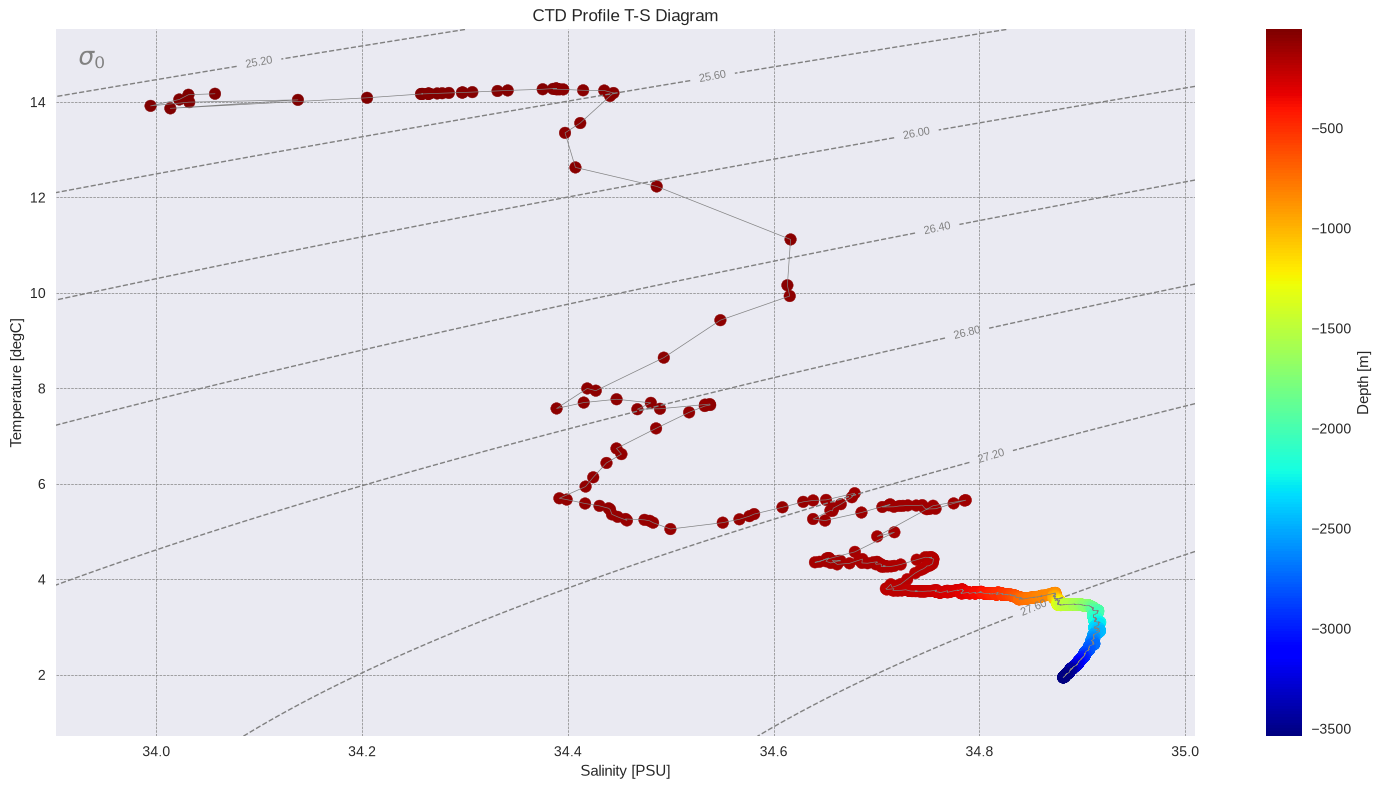

✓ T-S diagram created


In [8]:
# Add variable 'temperature' 
profile_data['temperature'] = profile_data['temperature_1']

ssl.plot('ts-diagram', profile_data, title="CTD Profile T-S Diagram")
print("✓ T-S diagram created")


### 4.2 Vertical Profile Plot

Display the CTD cast as a vertical profile showing how parameters change with depth:

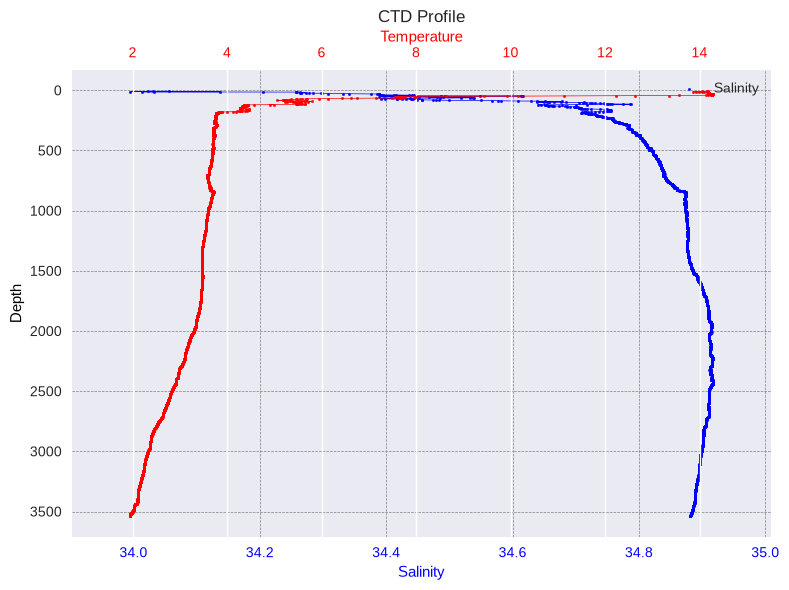

✓ Vertical profile plot created


In [9]:
# Create vertical profile plot using the new API
ssl.plot('depth-profile', profile_data, title="CTD Profile")
print("✓ Vertical profile plot created")

### 4.3 Time Series Plots

For the moored instrument data, let's create time series plots:

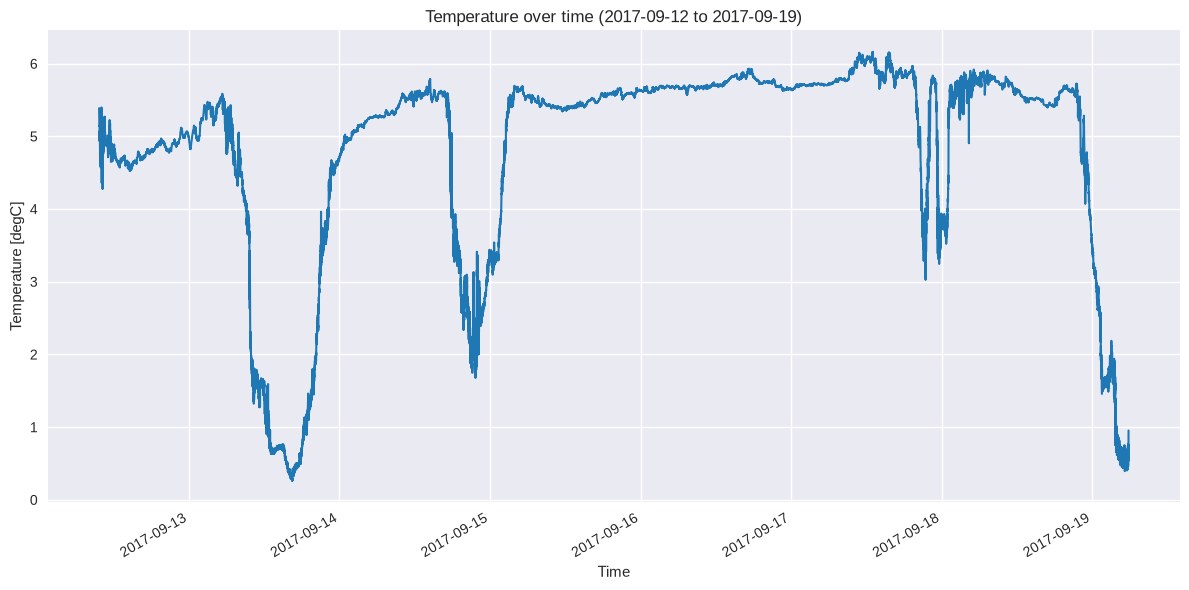

✓ Temperature time series created


In [10]:
ssl.plot('time-series', timeseries_data, parameters=['temperature'], title="Temperature Time Series")
print("✓ Temperature time series created")


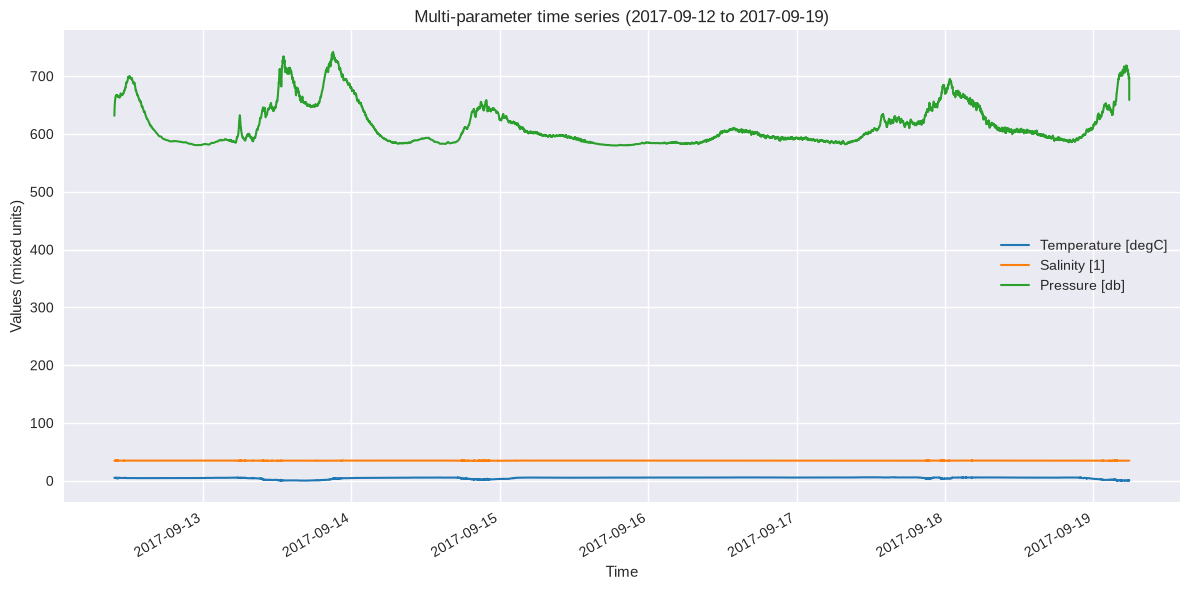

✓ Multi-parameter time series created for: ['temperature', 'salinity']


In [11]:
# Multi-parameter time series
# You can plot multiple parameters at once, but this plotter uses the same y-axis limits for all parameters.
available_ts_params = [p for p in ['temperature', 'salinity', 'pressure'] if p in timeseries_data.data_vars]

if len(available_ts_params) >= 2:
    ssl.plot('time-series', timeseries_data, parameters=available_ts_params, title="CTD Profile T-S Diagram")
    print(f"✓ Multi-parameter time series created for: {available_ts_params[:2]}")
else:
    print(f"Insufficient parameters for multi-plot. Available: {available_ts_params}")

## 5. Further data tools

SeaSenseLib provides basic tools for subsetting and statistics:

### 5.1 Data Subsetting

Extract specific depth ranges or time periods:

In [12]:
# Subset profile data by depth (if pressure/depth data available)
subset_processor = SubsetProcessor(profile_data)

if 'pressure' in profile_data.data_vars:
    # Subset to upper 50 dbar (approximately 50 meters)
    shallow_data = subset_processor.set_parameter_name('pressure').set_parameter_value_min(0).set_parameter_value_max(50).get_subset()
    print(f"Original data points: {len(profile_data.pressure)}")
    print(f"Shallow subset (0-50 dbar): {len(shallow_data.pressure)}")
    print(f"Pressure range in subset: {shallow_data.pressure.min().values:.1f} - {shallow_data.pressure.max().values:.1f} dbar")
else:
    print("Pressure data not available for depth subsetting")

Original data points: 3593
Shallow subset (0-50 dbar): 44
Pressure range in subset: 7.0 - 50.0 dbar


In [13]:
import pandas as pd
# Subset time series data by time period
if 'time' in timeseries_data.coords and len(timeseries_data.time) > 100:
    ts_subset_processor = SubsetProcessor(timeseries_data)
    # Get the first half of the time series
    start_time = timeseries_data.time.min()
    mid_time = timeseries_data.time[len(timeseries_data.time)//2]
    
    first_half = ts_subset_processor.set_time_min(pd.Timestamp(start_time.values)).set_time_max(pd.Timestamp(mid_time.values)).get_subset()

    print(f"Original time series length: {len(timeseries_data.time)}")
    print(f"First half subset length: {len(first_half.time)}")
    print(f"Time range in subset: {first_half.time.min().values} to {first_half.time.max().values}")
else:
    print("Time data not suitable for subsetting")

Original time series length: 59088
First half subset length: 29545
Time range in subset: 2017-09-12T09:40:29.000000 to 2017-09-15T19:44:29.000000


### 5.2 Statistical Analysis

Calculate statistics for the datasets:

In [14]:
# Compare statistics between full profile and shallow subset
if 'pressure' in profile_data.data_vars and 'temperature' in profile_data.data_vars:
    full_temp_processor = StatisticsProcessor(profile_data, 'temperature')
    full_stats = full_temp_processor.get_all_statistics()
    
    shallow_temp_processor = StatisticsProcessor(shallow_data, 'temperature')
    shallow_stats = shallow_temp_processor.get_all_statistics()
    
    print("=== Temperature Statistics Comparison ===")
    print(f"Full profile - Mean: {full_stats['mean']:.3f}°C, Range: {full_stats['min']:.3f} - {full_stats['max']:.3f}°C")
    print(f"Shallow (0-50m) - Mean: {shallow_stats['mean']:.3f}°C, Range: {shallow_stats['min']:.3f} - {shallow_stats['max']:.3f}°C")
    
    temp_diff = shallow_stats['mean'] - full_stats['mean']
    print(f"\nTemperature difference (shallow - full): {temp_diff:.3f}°C")
    if temp_diff > 0:
        print("→ Shallow waters are warmer (typical thermocline pattern)")
    else:
        print("→ Shallow waters are cooler")

=== Temperature Statistics Comparison ===
Full profile - Mean: 3.318°C, Range: 1.944 - 14.286°C
Shallow (0-50m) - Mean: 13.701°C, Range: 9.430 - 14.286°C

Temperature difference (shallow - full): 10.382°C
→ Shallow waters are warmer (typical thermocline pattern)


## Next Steps

To learn more about SeaSenseLib:

1. **Documentation**: Check the full documentation for detailed API reference
2. **CLI Usage**: Try the command-line interface with `seasenselib --help`
3. **More Formats**: Explore support for RBR, ADCP, and other instrument formats (see the Moored Instruments demo)
4. **Custom Processing**: Implement custom readers and processors for your specific needs
5. **Integration**: Integrate SeaSenseLib into your oceanographic data processing workflows

### Example CLI Commands

```bash
# List supported formats
seasenselib formats

# Convert CNV to NetCDF
seasenselib convert -i examples/sea-practical-2023.cnv -o output.nc

# Create plots
seasenselib plot ts-diagram -i output.nc -o ts_diagram.png
seasenselib plot depth-profile -i output.nc -o profile.png
seasenselib plot time-series -i examples/denmark-strait-ds-m1-17.cnv -p temperature
```

Happy oceanographic data processing! 🌊